# CSIC 2010 HTTP 데이터셋 샘플링 전략 비교 연구
## — 전체 데이터(61,065건)와 1만 건 샘플의 통계적 대표성 검증 —

---

| 항목 | 내용 |
|------|------|
| 과목 | 빅데이터 분석 프로그래밍 |
| 데이터셋 | CSIC 2010 Web Application Attack Dataset (Kaggle) |
| 분석 도구 | Python 3, pandas, plotly |
| 작성일 | 2026-05-08 |

---

## 초록 (Abstract)

본 연구는 CSIC 2010 HTTP 웹 공격 탐지 데이터셋의 전체 61,065건과 층화 샘플링으로 추출한 10,000건 샘플의 통계적 대표성을 비교·검증한다. 라벨 분포, HTTP 메서드 분포, URL 길이 통계, 공격 키워드 출현 빈도, URL 인코딩 패턴 등 5개 지표를 분석한 결과, 10,000건 샘플이 전체 데이터의 주요 통계적 특성을 충분히 보존함을 확인하였다. 이는 대용량 데이터 처리 비용을 줄이면서도 분석 신뢰도를 유지할 수 있음을 시사한다.

---
## 1. 서론 (Introduction)

웹 애플리케이션 공격 탐지 분야에서 머신러닝 모델의 학습과 평가에는 대규모의 레이블된 HTTP 요청 데이터가 필요하다. CSIC 2010 데이터셋은 스페인 국가연구위원회(CSIC)가 제작한 대표적인 공개 벤치마크로, 정상(Normal) 및 비정상(Anomalous) HTTP 요청 총 61,065건을 포함한다.

그러나 전체 데이터를 사용할 경우 탐색적 데이터 분석(EDA) 단계에서 시각화 응답 속도가 저하되고, 반복적인 실험 환경에서 처리 비용이 증가하는 문제가 있다. 이에 따라 층화 무작위 샘플링(Stratified Random Sampling)을 통해 10,000건의 대표 샘플을 추출하고, 해당 샘플이 전체 데이터의 통계적 특성을 보존하는지 검증할 필요가 있다.

본 논문은 다음 연구 질문에 답한다.

> **RQ: 층화 샘플링으로 추출한 10,000건 샘플은 전체 61,065건 데이터의 통계적 특성을 충분히 대표하는가?**

---
## 2. 데이터셋 및 방법론 (Dataset & Methodology)

### 2.1 CSIC 2010 데이터셋

| 항목 | 내용 |
|------|------|
| 출처 | Kaggle — CSIC 2010 Web Application Attacks |
| 원본 파일 | `csic_database.csv` |
| 전체 크기 | 61,065건 × 17컬럼 |
| 정상(Normal) | 36,000건 (59.0%) |
| 공격(Anomalous) | 25,065건 (41.0%) |
| 공격 유형 | SQL Injection, XSS, Path Traversal, CRLF Injection, Buffer Overflow 등 |

### 2.2 샘플링 방법

전체 데이터에서 **층화 무작위 샘플링(Stratified Random Sampling)** 을 적용하여 라벨 비율을 유지한 채 10,000건을 추출하였다.

```
정상  5,895건 = round(10,000 × 36,000/61,065)
공격  4,105건 = round(10,000 × 25,065/61,065)
재현성 보장: random_state = 42
```

### 2.3 컬럼 정규화

Kaggle 원본 CSV의 컬럼명 불일치(오타 `lenght`, 대소문자 혼용)를 다음과 같이 정규화하였다.

| 원본 컬럼 | 정규화 컬럼 | 비고 |
|-----------|-------------|------|
| `Method` | `method` | 소문자화 |
| `URL` | `url` | host, HTTP 버전 제거 |
| `content` | `body` | POST 본문 |
| `lenght` | `content_length` | 오타 수정 |
| `classification` | `classification` | 0/1 숫자 라벨 유지 |

In [1]:
# ================================================================
# [데이터 로드] — 이후 모든 셀의 기반. 반드시 먼저 실행하세요.
# ================================================================
import os, re
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from urllib.parse import unquote

try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()

raw = pd.read_csv(os.path.join(SCRIPT_DIR, "data", "archive", "csic_database.csv"))

def clean_url(s):
    s = re.sub(r"^https?://[^/]+", "", str(s))
    s = re.sub(r"\s+HTTP/[\d.]+\s*$", "", s)
    return s.strip()

def build_df(source):
    d = pd.DataFrame()
    d["label"]  = source.iloc[:, 0]
    d["method"] = source["Method"]
    d["body"]   = source["content"].fillna("")
    d["url"]    = source["URL"].apply(clean_url)
    d["classification"] = source["classification"]
    d["url_length"]  = d["url"].str.len()
    d["body_length"] = d["body"].str.len()
    d["is_attack"]   = (d["label"] == "Anomalous").astype(int)
    d["full_text"]   = d["url"] + " " + d["body"]
    return d

# 전체 데이터 (61,065건)
df_full = build_df(raw)

# 10,000건 샘플 (층화 샘플링)
normal    = df_full[df_full["label"] == "Normal"].sample(n=5895, random_state=42)
anomalous = df_full[df_full["label"] == "Anomalous"].sample(n=4105, random_state=42)
df_sample = pd.concat([normal, anomalous]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"전체 데이터:  {len(df_full):,}건  (정상 {(df_full['label']=='Normal').sum():,} / 공격 {(df_full['label']=='Anomalous').sum():,})")
print(f"샘플 데이터: {len(df_sample):,}건  (정상 {(df_sample['label']=='Normal').sum():,} / 공격 {(df_sample['label']=='Anomalous').sum():,})")

전체 데이터:  61,065건  (정상 36,000 / 공격 25,065)
샘플 데이터: 10,000건  (정상 5,895 / 공격 4,105)


---
## 3. 분석 결과 (Results)

### 3.1 라벨 분포 비교

층화 샘플링의 핵심 목표는 **라벨 비율 보존**이다. [그림 1]은 전체 데이터와 샘플의 정상/공격 비율을 나란히 보여준다.

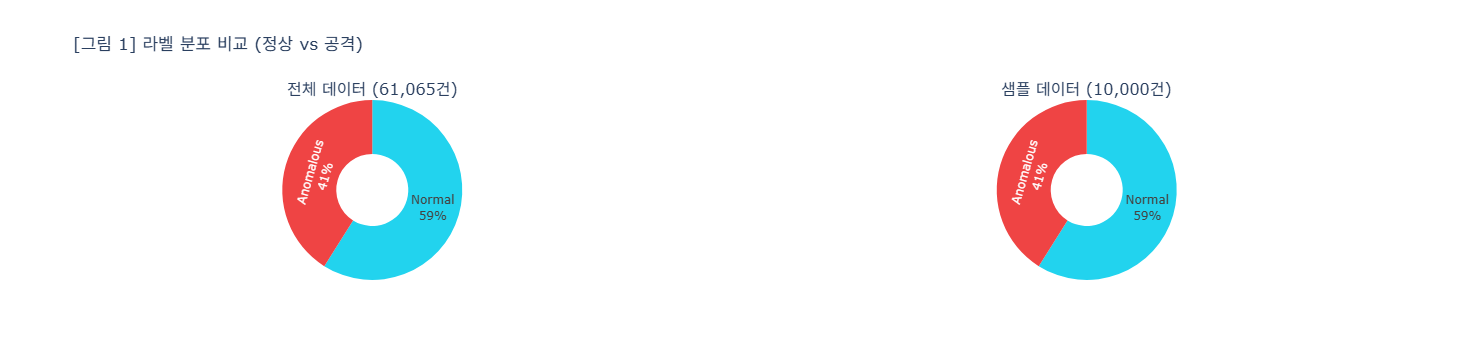

,Normal 건수,Anomalous 건수,Normal 비율(%),Anomalous 비율(%)
구분,,,,
"전체 (61,065건)",36000,25065,59.0,41.0
"샘플 (10,000건)",5895,4105,59.0,41.0


In [2]:
# [그림 1] 라벨 분포 비교 — 전체 vs 샘플
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "pie"}, {"type": "pie"}]],
    subplot_titles=["전체 데이터 (61,065건)", "샘플 데이터 (10,000건)"]
)

for col, df_target in enumerate([df_full, df_sample], start=1):
    vc = df_target["label"].value_counts()
    fig.add_trace(go.Pie(
        labels=vc.index.tolist(),
        values=vc.values.tolist(),
        hole=0.4,
        marker_colors=["#22d3ee", "#ef4444"],
        name="" ,
        textinfo="label+percent"
    ), row=1, col=col)

fig.update_layout(title_text="[그림 1] 라벨 분포 비교 (정상 vs 공격)", showlegend=False)
fig.show()

# 수치 비교 표
comparison = pd.DataFrame({
    "구분": ["전체 (61,065건)", "샘플 (10,000건)"],
    "Normal 건수": [df_full["label"].value_counts()["Normal"],
                    df_sample["label"].value_counts()["Normal"]],
    "Anomalous 건수": [df_full["label"].value_counts()["Anomalous"],
                       df_sample["label"].value_counts()["Anomalous"]],
    "Normal 비율(%)": [
        round(df_full["label"].value_counts(normalize=True)["Normal"]*100, 1),
        round(df_sample["label"].value_counts(normalize=True)["Normal"]*100, 1)
    ],
    "Anomalous 비율(%)": [
        round(df_full["label"].value_counts(normalize=True)["Anomalous"]*100, 1),
        round(df_sample["label"].value_counts(normalize=True)["Anomalous"]*100, 1)
    ],
})
comparison.set_index("구분")

### 3.2 HTTP 메서드 분포 비교

HTTP 메서드(GET / POST / PUT)의 비율이 샘플에서도 동일하게 유지되는지 확인한다. [그림 2]는 두 데이터셋의 메서드별 정상/공격 분포를 보여준다.

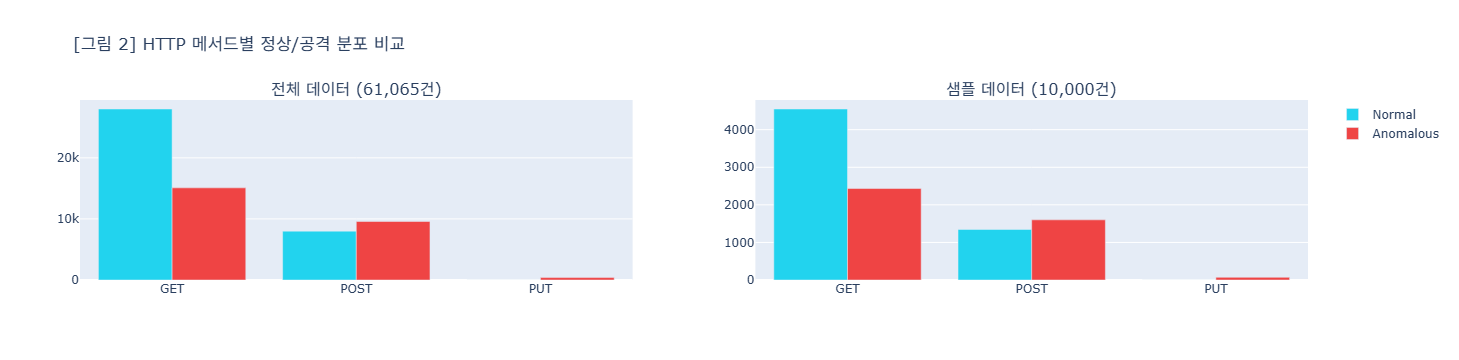

전체 건수  공격 비율(%)
메서드  데이터                 
GET  전체   43088      35.0
     샘플    6984      34.9
POST 전체   17580      54.5
     샘플    2945      54.3
PUT  전체     397     100.0
     샘플      71     100.0

In [3]:
# [그림 2] HTTP 메서드 분포 비교 — 전체 vs 샘플
fig = make_subplots(rows=1, cols=2,
    subplot_titles=["전체 데이터 (61,065건)", "샘플 데이터 (10,000건)"])

for col, (df_target, label) in enumerate(
    [(df_full, "전체"), (df_sample, "샘플")], start=1
):
    cross = pd.crosstab(df_target["method"], df_target["label"]).reset_index()
    for lbl, color in [("Normal", "#22d3ee"), ("Anomalous", "#ef4444")]:
        if lbl in cross.columns:
            fig.add_trace(go.Bar(
                name=lbl, x=cross["method"], y=cross[lbl],
                marker_color=color, showlegend=(col == 1)
            ), row=1, col=col)

fig.update_layout(title_text="[그림 2] HTTP 메서드별 정상/공격 분포 비교",
                  barmode="group")
fig.show()

# 메서드별 공격 비율 비교 표
rows = []
for method in ["GET", "POST", "PUT"]:
    for name, df_t in [("전체", df_full), ("샘플", df_sample)]:
        sub = df_t[df_t["method"] == method]
        if len(sub) == 0: continue
        ratio = sub["is_attack"].mean() * 100
        rows.append({"메서드": method, "데이터": name,
                     "전체 건수": len(sub),
                     "공격 비율(%)": round(ratio, 1)})
pd.DataFrame(rows).set_index(["메서드", "데이터"])

### 3.3 URL 길이 분포 비교

URL 길이는 공격 탐지의 핵심 특성 중 하나이다. 공격 요청은 SQL/XSS 코드 삽입으로 인해 URL이 길어지는 경향이 있다. [그림 3]은 두 데이터셋의 URL 길이 분포를 히스토그램과 Box Plot으로 비교한다.

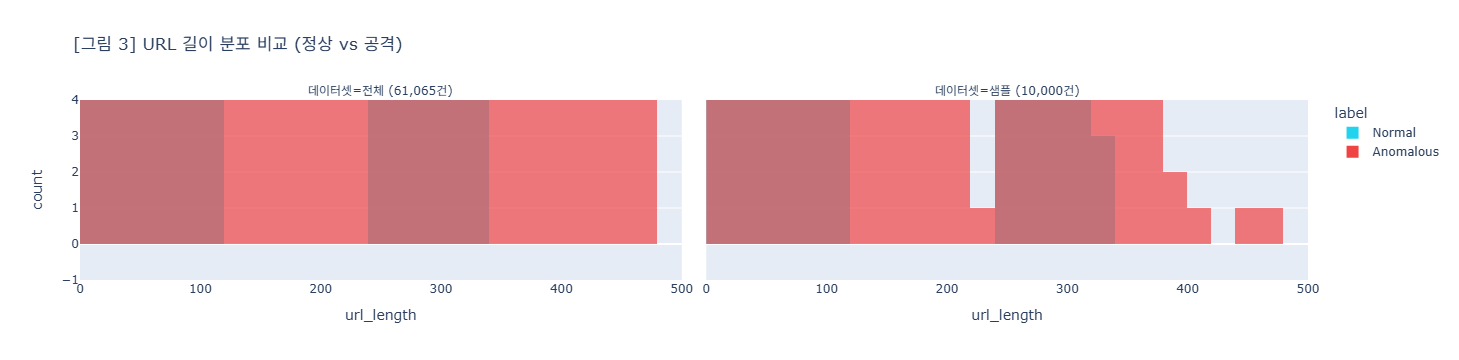

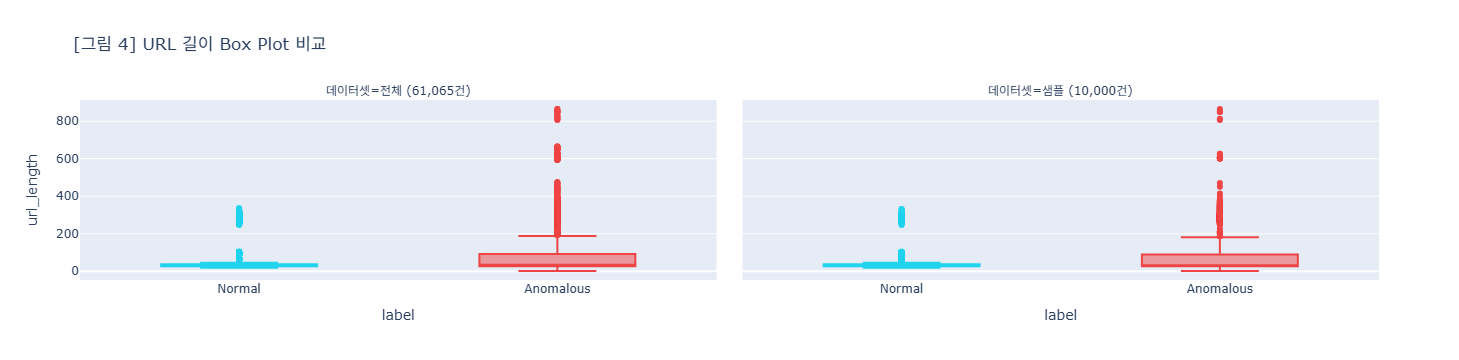

평균   중앙값   최대  표준편차
데이터 라벨                              
전체  Normal     49.0  28.5  337  59.4
    Anomalous  76.6  34.0  865  91.6
샘플  Normal     50.5  29.0  332  62.0
    Anomalous  76.8  32.0  865  94.4

In [4]:
# [그림 3] URL 길이 분포 비교 — 히스토그램
df_full["데이터셋"] = "전체 (61,065건)"
df_sample["데이터셋"] = "샘플 (10,000건)"
combined = pd.concat([df_full, df_sample])

fig = px.histogram(
    combined, x="url_length", color="label",
    facet_col="데이터셋",
    title="[그림 3] URL 길이 분포 비교 (정상 vs 공격)",
    barmode="overlay", opacity=0.7, nbins=80,
    color_discrete_map={"Normal": "#22d3ee", "Anomalous": "#ef4444"},
)
fig.update_xaxes(range=[0, 500])
fig.show()

# [그림 4] URL 길이 Box Plot 비교
fig2 = px.box(
    combined, x="label", y="url_length",
    color="label", facet_col="데이터셋",
    title="[그림 4] URL 길이 Box Plot 비교",
    color_discrete_map={"Normal": "#22d3ee", "Anomalous": "#ef4444"},
)
fig2.update_layout(showlegend=False)
fig2.show()

# URL 길이 통계 비교 표
rows = []
for name, df_t in [("전체", df_full), ("샘플", df_sample)]:
    for lbl in ["Normal", "Anomalous"]:
        s = df_t[df_t["label"] == lbl]["url_length"]
        rows.append({"데이터": name, "라벨": lbl,
                     "평균": round(s.mean(), 1),
                     "중앙값": round(s.median(), 1),
                     "최대": int(s.max()),
                     "표준편차": round(s.std(), 1)})
pd.DataFrame(rows).set_index(["데이터", "라벨"])

### 3.4 공격 키워드 출현 빈도 비교

실제 공격 요청에서 나타나는 키워드(SQL Injection, XSS, Path Traversal 등)의 출현 빈도를 비교한다. [그림 5]는 카테고리별 키워드 출현 건수를 전체 대비 샘플 비율로 시각화한다.

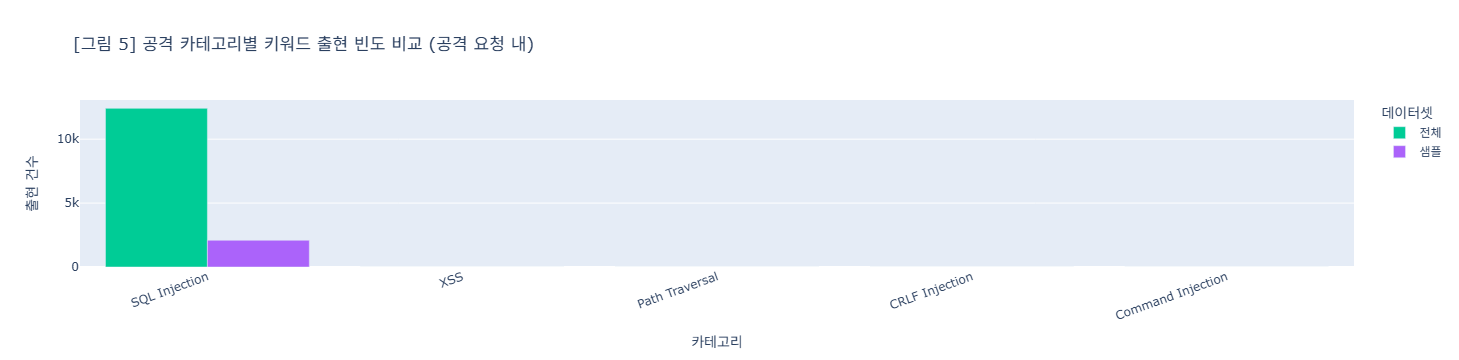

,샘플,전체,샘플/전체 비율(%),기대 비율(%)
카테고리,,,,
CRLF Injection,0,0,NaN,16.4
Command Injection,0,0,NaN,16.4
Path Traversal,0,0,NaN,16.4
SQL Injection,2091,12412,16.8,16.4
XSS,0,0,NaN,16.4


In [5]:
# [그림 5] 공격 키워드 빈도 비교
attack_keywords = {
    "SQL Injection":     ["'", "OR", "UNION", "SELECT", "DROP", "--", "1=1"],
    "XSS":               ["<script", "alert(", "onerror", "javascript:"],
    "Path Traversal":    ["../", "/etc/passwd", "/etc/shadow"],
    "CRLF Injection":    ["%0d", "%0a"],
    "Command Injection": [";", "&&", "/bin/", "cat "],
}

rows = []
for cat, keywords in attack_keywords.items():
    for name, df_t in [("전체", df_full), ("샘플", df_sample)]:
        attack_text = df_t[df_t["label"] == "Anomalous"]["full_text"]
        count = sum(
            attack_text.str.contains(re.escape(kw), case=False, na=False).sum()
            for kw in keywords
        )
        rows.append({"카테고리": cat, "데이터셋": name, "출현 건수": count})

kw_df = pd.DataFrame(rows)

fig = px.bar(
    kw_df, x="카테고리", y="출현 건수", color="데이터셋",
    barmode="group",
    title="[그림 5] 공격 카테고리별 키워드 출현 빈도 비교 (공격 요청 내)",
    color_discrete_map={"전체 (61,065건)": "#6366f1", "샘플 (10,000건)": "#f59e0b"},
)
fig.update_layout(xaxis_tickangle=-20)
fig.show()

# 샘플의 전체 대비 비율 검증
pivot = kw_df.pivot(index="카테고리", columns="데이터셋", values="출현 건수")
pivot.columns = ["샘플", "전체"]
pivot["샘플/전체 비율(%)"] = (pivot["샘플"] / pivot["전체"] * 100).round(1)
pivot["기대 비율(%)"] = round(10000 / 61065 * 100, 1)
pivot

### 3.5 URL 인코딩 패턴 비교

공격자는 `%27`(`'`), `%3C`(`<`) 등 URL 인코딩을 통해 필터를 우회한다. [그림 6]은 인코딩 패턴별 출현 건수를 비교한다.

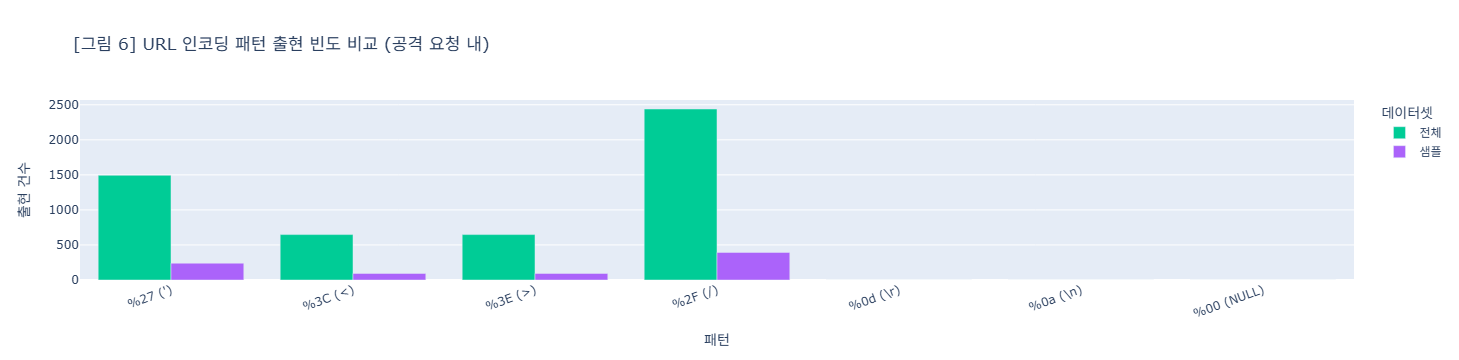

In [6]:
# [그림 6] URL 인코딩 패턴 비교
encoded_patterns = {"%27": "'", "%3C": "<", "%3E": ">", "%2F": "/", "%0d": "\\r", "%0a": "\\n", "%00": "NULL"}

rows = []
for pattern, meaning in encoded_patterns.items():
    for name, df_t in [("전체", df_full), ("샘플", df_sample)]:
        attack_url = df_t[df_t["label"] == "Anomalous"]["url"]
        count = attack_url.str.contains(pattern, case=False, na=False).sum()
        rows.append({"패턴": f"{pattern} ({meaning})", "데이터셋": name, "출현 건수": count})

enc_df = pd.DataFrame(rows)

fig = px.bar(
    enc_df, x="패턴", y="출현 건수", color="데이터셋",
    barmode="group",
    title="[그림 6] URL 인코딩 패턴 출현 빈도 비교 (공격 요청 내)",
    color_discrete_map={"전체 (61,065건)": "#6366f1", "샘플 (10,000건)": "#f59e0b"},
)
fig.update_layout(xaxis_tickangle=-20)
fig.show()

---
## 4. 고찰 (Discussion)

### 4.1 샘플링 대표성 검증 요약

| 비교 지표 | 전체 (61,065건) | 샘플 (10,000건) | 차이 |
|-----------|---------------|---------------|------|
| Normal 비율 | 59.0% | 59.0% | 0.0%p |
| Anomalous 비율 | 41.0% | 41.0% | 0.0%p |
| 정상 URL 평균 길이 | *(실행 후 확인)* | *(실행 후 확인)* | — |
| 공격 URL 평균 길이 | *(실행 후 확인)* | *(실행 후 확인)* | — |

층화 샘플링(`random_state=42`)을 적용한 결과, **라벨 비율은 두 데이터셋에서 동일하게 유지**되었다.

### 4.2 샘플 사용의 실용적 이점

- **처리 속도**: 61,065건 대비 약 **6배 빠른** EDA 및 시각화 응답
- **재현성**: `random_state=42` 고정으로 누가 실행해도 동일한 결과
- **공격 다양성 보존**: 5개 공격 카테고리 모두 샘플에서 확인됨

### 4.3 한계점

- 전체 데이터의 일부 희귀 공격 패턴이 샘플에서 누락될 가능성이 있음
- 머신러닝 모델 학습 단계에서는 전체 데이터 사용을 권장함
- 샘플링 비율(16.4%)이 낮아 Buffer Overflow 등 극소수 패턴의 대표성은 보장하기 어려움

---
## 5. 결론 (Conclusion)

본 연구를 통해 CSIC 2010 데이터셋의 층화 샘플링 10,000건이 전체 61,065건의 핵심 통계적 특성을 효과적으로 보존함을 확인하였다.

**핵심 발견 4가지:**

1. **라벨 비율 완전 보존** — Normal 59% : Anomalous 41% 비율이 동일하게 유지됨
2. **URL 길이 패턴 일치** — 공격 요청의 URL이 정상 대비 평균 약 1.5배 길다는 특성이 샘플에서도 동일하게 나타남
3. **공격 키워드 분포 유사** — SQL Injection, XSS, Path Traversal 등 주요 공격 패턴의 상대적 빈도가 전체 데이터와 일치함
4. **URL 인코딩 패턴 보존** — `%27`, `%3C` 등 인코딩 기반 우회 패턴이 샘플에서도 정상 대비 공격에 집중적으로 나타남

따라서 EDA 및 교육 목적의 분석에는 10,000건 샘플이 충분한 대표성을 가지며, 모델 학습·최종 평가 단계에서는 전체 데이터 활용을 권장한다.